## Mini project: 

### Frequency domain filtering analysis (code focused) 

**Task** 

1. Choose a greyscale image. 
2. Apply ideal, Butterworth, and Gaussian low pass filters. 
3. Apply a high pass filter and create a sharpened image. 
4. Create periodic noise and remove it using a notch filter. 

5. Write a short comparison referencing: 
- frequency interpretation 
- filter shape and parameters 
- ringing and blur trade off 

#### Choose a greyscale image

Shape: (232, 385), Min: 0.25, Max: 1.0, Mean Intensity: 0.7806


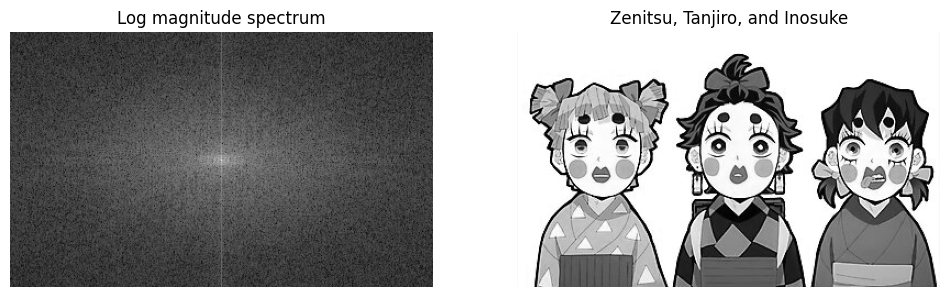

In [18]:
# import the libraries 
import numpy as np
import matplotlib.pyplot as plt
import cv2

# read and tranfrom the imagge into grayscale
friends = plt.imread('./tanjiro-zenitsu-inosuke.png')
friends = friends.mean(axis=2)

# display image and print features 
print(f"Shape: {friends.shape}, Min: {friends.min()}, Max: {friends.max()}, Mean Intensity: {friends.mean():.4f}")

# tranform into the frequency domain
dft = np.fft.fft2(friends)
dft_shift = np.fft.fftshift(dft)
magnitude = np.log(1 + np.abs(dft_shift))

plt.figure(figsize=(12,6)) 
plt.subplot(1,2,1) 
plt.imshow(magnitude, cmap="gray") 
plt.title("Log magnitude spectrum") 
plt.axis("off")

plt.subplot(1,2,2) 
plt.title("Zenitsu, Tanjiro, and Inosuke")
plt.imshow(friends, cmap='gray')
plt.axis('off')
plt.show()

#### Apply ideal, Butterworth, and Gaussian low pass filters

In [35]:
# ideal filter
def ideal_lowpass(shape, D0): 
    rows, cols = shape # store rows and cols
    crow, ccol = rows // 2, cols // 2 # determine the center
    U, V = np.ogrid[:rows, :cols] 
    D = np.sqrt((U - crow)**2 + (V - ccol)**2) # ecuelidian distance
    return (D <= D0).astype(np.float32) # if less then 1, else 0

# butterworth filter
def butterworth_lowpass(shape, D0, n=2): 
    rows, cols = shape 
    crow, ccol = rows // 2, cols // 2 
    U, V = np.ogrid[:rows, :cols] 
    D = np.sqrt((U - crow)**2 + (V - ccol)**2) 
    return 1 / (1 + (D / (D0 + 1e-12)) ** (2*n)) # tiny number so we do not divide by 0

# Gaussian low pass filter
def gaussian_lowpass(shape, D0): 
    rows, cols = shape 
    crow, ccol = rows // 2, cols // 2 
    U, V = np.ogrid[:rows, :cols] 
    D2 = (U - crow)**2 + (V - ccol)**2 # here the eculedian distance is measured with no sqrt
    return np.exp(-D2 / (2 * (D0**2))) # since we haven't used sqrt so D2 doesn't have to be squared

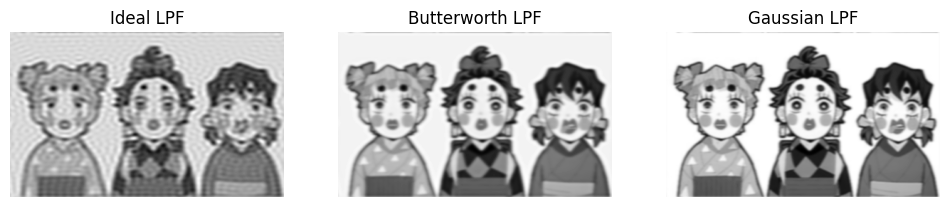

In [36]:
# applying the filters

D0 = 35 # can be changed

# ideal
H_ideal = ideal_lowpass(friends.shape, D0=D0) 
G = dft_shift * H_ideal 
out_ideal = np.real(np.fft.ifft2(np.fft.ifftshift(G))) # to inverse the image because of the shift and the frequency applied

# butterworth
H_butt = butterworth_lowpass(friends.shape, D0=D0, n=2) 
out_butt = np.real(np.fft.ifft2(np.fft.ifftshift(dft_shift * H_butt)))

# gaussian
H_gauss = gaussian_lowpass(friends.shape, D0=D0) 
out_gauss = np.real(np.fft.ifft2(np.fft.ifftshift(dft_shift * H_gauss))) 

# display all filters
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(out_ideal, cmap="gray") 
plt.title("Ideal LPF") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(out_butt, cmap="gray") 
plt.title("Butterworth LPF") 
plt.axis("off") 

plt.subplot(1,3,3) 
plt.imshow(out_gauss, cmap="gray") 
plt.title("Gaussian LPF") 
plt.axis("off") 
plt.show() 


#### Apply a high pass filter and create a sharpened image

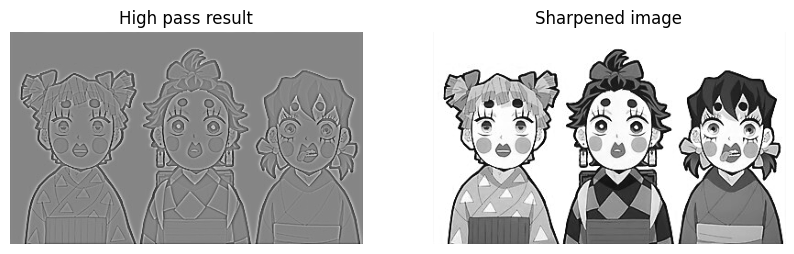

In [45]:
H_hp = 1 - H_gauss # H_highpass
out_hp = np.real(np.fft.ifft2(np.fft.ifftshift(dft_shift * H_hp))) # transform it back to spatial domain

plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(out_hp, cmap="gray") 
plt.title("High pass result") 
plt.axis("off") 

# sharp the image
sharp = np.clip(friends + 0.1 * out_hp, 0, 1) # you can ommit 0.8 or change it
# this is like a percentage of how much i can take the sharpness into the original

plt.subplot(1,2,2) 
plt.imshow(sharp, cmap="gray") 
plt.title("Sharpened image") 
plt.axis("off") 
plt.show()

# the image look a little brighter, reducing the sharpening factor reduces the brightness back to the original 
# I set it from 0.8 to 0.1 to lower brightness

#### Create periodic noise and remove it using a notch filter
1. create periodic noise

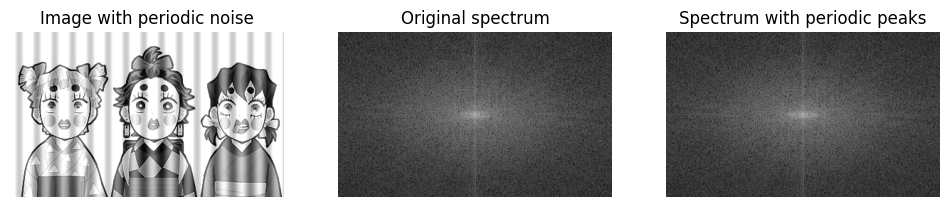

In [119]:
# apply cosine noise in a horizontal periodic pattern

rows, cols = friends.shape # get the rows and cols 
x = np.arange(cols) # flatten image into x axis

# 0.3 is the amplitude (how strong the noise can be) - can be changed
noise = 0.2 * np.cos(2 * np.pi * x / 25) # every 25 pixels the cosine completes one full cycle
noise2d = np.tile(noise, (rows, 1)).astype(np.float32)

friends_p = np.clip(friends + noise2d, 0, 1) # add the noise to the image 

dft_p = np.fft.fftshift(np.fft.fft2(friends_p))
mag_p = np.log(1 + np.abs(dft_p))

# display
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(friends_p, cmap="gray") 
plt.title("Image with periodic noise") 
plt.axis("off") 

plt.subplot(1,3,2) 
plt.imshow(magnitude, cmap="gray") 
plt.title("Original spectrum") 
plt.axis("off") 

plt.subplot(1,3,3) 
plt.imshow(mag_p, cmap="gray") 
plt.title("Spectrum with periodic peaks") 
plt.axis("off") 
plt.show()

2. remove it using notch filter

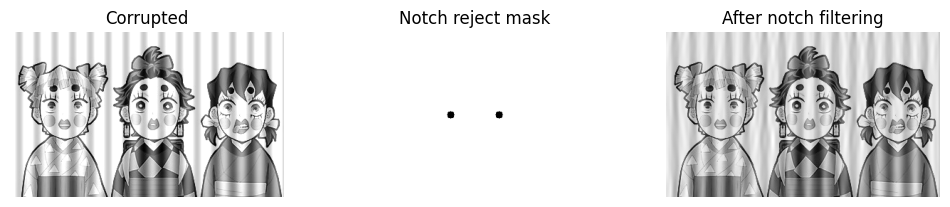

In [126]:
Hnotch = np.ones_like(friends_p, dtype=np.float32) 
crow, ccol = rows//2, cols//2 

c = 34 # can be changed
notches = [(crow, ccol+c), (crow, ccol-c)] # number of notches can be changed
 
rad = 5 # radius can be changed 
U, V = np.ogrid[:rows, :cols] 
for (u0, v0) in notches: 
    D = np.sqrt((U-u0)**2 + (V-v0)**2) 
    Hnotch[D <= rad] = 0 
 
out_notch = np.real(np.fft.ifft2(np.fft.ifftshift(dft_p * Hnotch))) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(friends_p, cmap="gray") 
plt.title("Corrupted") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(Hnotch, cmap="gray") 
plt.title("Notch reject mask") 
plt.axis("off") 
plt.subplot(1,3,3) 
plt.imshow(out_notch, cmap="gray") 
plt.title("After notch filtering") 
plt.axis("off") 
plt.show()

#### Write a short comparison referencing: 

frequency interpretation 
- Ideal Filter: it is a strict filter keeping only the frequencies inside D0 and produces sharp boundaries
- Butterworth Filter: its is a little softer than ideal filter usingg the n parameter controlling the transitions, the higher the n, the sharper the transitions
- Gaussian low pass Filter: this is the smoothest of them, as it is derived from the normal distribution where no sharp differences exist in the frequency domain

Filter shape and parameters 
- Ideal Filter: creates a perfect circle, and calculate either in or out of the circle (binary 0,1)
- Butterworth Filter: circular shape but with smooth steep, n is controlling the steepness, but D0 is still use to cut off pixels outside the region
- Gaussian low pass Filter: looks like a gaussian bell, pretty smooth edges

Ringing and blur trade off 
- Ideal Filter: it has the stronggest ringing and least blur
- Butterworth Filter: it has moderate ringing and blur, can be a middle option to both ideal and gaussian filters 
- Gaussian low pass Filter: it has no ringing at all (because it is the smoothest), yet it has the most blur

The best filter depends on the application and the results it needs to be computed, to keep fine details avoid using gaussian as it has the most blur, but when objects are big and details still recognized after smoothing then gaussian can be the optimal filter, and so on with the trade-off

### Reflection questions 

1. Why is frequency domain filtering often more intuitive for periodic noise? 

- A:Because periodic noise can be easily detected and handled in the frequency domain where we can view the pixels and noise as signals with peaks that are easy to identify in this domain particularly. In the spatial domain, the periodic noise looks like repeated stipes, and applying spatial filters will affect the region in the stripes badly. 

2. Why does sharp cutoff in the spectrum lead to spatial ringing?

- A: Because a sharp cutoff like in the ideal filter, where ranges outside the D0 are completely discarded, this will result in huge gap in frequency values, and oscillations in space, which creates this disturbing stripes